In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input/brain-tumor-mri-dataset"):
    for d in dirs:
        print(os.path.join(root, d))


/kaggle/input/brain-tumor-mri-dataset/Training
/kaggle/input/brain-tumor-mri-dataset/Testing
/kaggle/input/brain-tumor-mri-dataset/Training/pituitary
/kaggle/input/brain-tumor-mri-dataset/Training/notumor
/kaggle/input/brain-tumor-mri-dataset/Training/meningioma
/kaggle/input/brain-tumor-mri-dataset/Training/glioma
/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary
/kaggle/input/brain-tumor-mri-dataset/Testing/notumor
/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma
/kaggle/input/brain-tumor-mri-dataset/Testing/glioma


In [ ]:
import os

# Define the base directories
train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_dir  = "/kaggle/input/brain-tumor-mri-dataset/Testing"

def count_images_in_subfolders(base_dir):
    print(f"\n📁 Image counts in: {base_dir}\n")
    total = 0
    for folder in sorted(os.listdir(base_dir)):
        folder_path = os.path.join(base_dir, folder)
        if os.path.isdir(folder_path):
            count = len([
                f for f in os.listdir(folder_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            print(f"{folder:20s} : {count} images")
            total += count
    print(f"➡️ Total images in {os.path.basename(base_dir)}: {total}\n")
    return total

# Count images in both folders
train_total = count_images_in_subfolders(train_dir)
test_total  = count_images_in_subfolders(test_dir)

print(f"✅ Grand Total (Training + Testing): {train_total + test_total} images")



📁 Image counts in: /kaggle/input/brain-tumor-mri-dataset/Training

glioma               : 1321 images
meningioma           : 1339 images
notumor              : 1595 images
pituitary            : 1457 images
➡️ Total images in Training: 5712


📁 Image counts in: /kaggle/input/brain-tumor-mri-dataset/Testing

glioma               : 300 images
meningioma           : 306 images
notumor              : 405 images
pituitary            : 300 images
➡️ Total images in Testing: 1311

✅ Grand Total (Training + Testing): 7023 images


In [ ]:
import os
import shutil

# Source directories
train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_dir  = "/kaggle/input/brain-tumor-mri-dataset/Testing"

# Destination directory
merged_dir = "/kaggle/working/Brain_Tumor_Merged"

# Create destination folder if it doesn’t exist
os.makedirs(merged_dir, exist_ok=True)

# Merge images from both directories
for src_dir in [train_dir, test_dir]:
    for folder in os.listdir(src_dir):
        src_folder = os.path.join(src_dir, folder)
        if os.path.isdir(src_folder):
            dest_folder = os.path.join(merged_dir, folder)
            os.makedirs(dest_folder, exist_ok=True)
            for file in os.listdir(src_folder):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_path = os.path.join(src_folder, file)
                    dest_path = os.path.join(dest_folder, file)

                    # Avoid overwriting files with same name
                    if os.path.exists(dest_path):
                        base, ext = os.path.splitext(file)
                        i = 1
                        while os.path.exists(dest_path):
                            dest_path = os.path.join(dest_folder, f"{base}_{i}{ext}")
                            i += 1
                    shutil.copy2(src_path, dest_path)

print("✅ Merge completed! All images copied to:", merged_dir)

print("\n📊 Checking merged folder image counts:\n")
total = 0
for folder in os.listdir(merged_dir):
    folder_path = os.path.join(merged_dir, folder)
    if os.path.isdir(folder_path):
        count = len([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"{folder:20s} : {count} images")
        total += count
print(f"\n➡️ Total images in merged folder: {total}")


✅ Merge completed! All images copied to: /kaggle/working/Brain_Tumor_Merged

📊 Checking merged folder image counts:

glioma               : 1621 images
pituitary            : 1757 images
meningioma           : 1645 images
notumor              : 2000 images

➡️ Total images in merged folder: 7023



Processing class: glioma (1621 images)


glioma Progress: 100%|█████████████████████████████████████████| 1621/1621 [00:08<00:00, 189.29it/s]



Processing class: meningioma (1645 images)


meningioma Progress: 100%|█████████████████████████████████████| 1645/1645 [00:07<00:00, 209.18it/s]



Processing class: notumor (2000 images)


notumor Progress: 100%|████████████████████████████████████████| 2000/2000 [00:08<00:00, 222.95it/s]



Processing class: pituitary (1757 images)


pituitary Progress: 100%|██████████████████████████████████████| 1757/1757 [00:08<00:00, 197.08it/s]


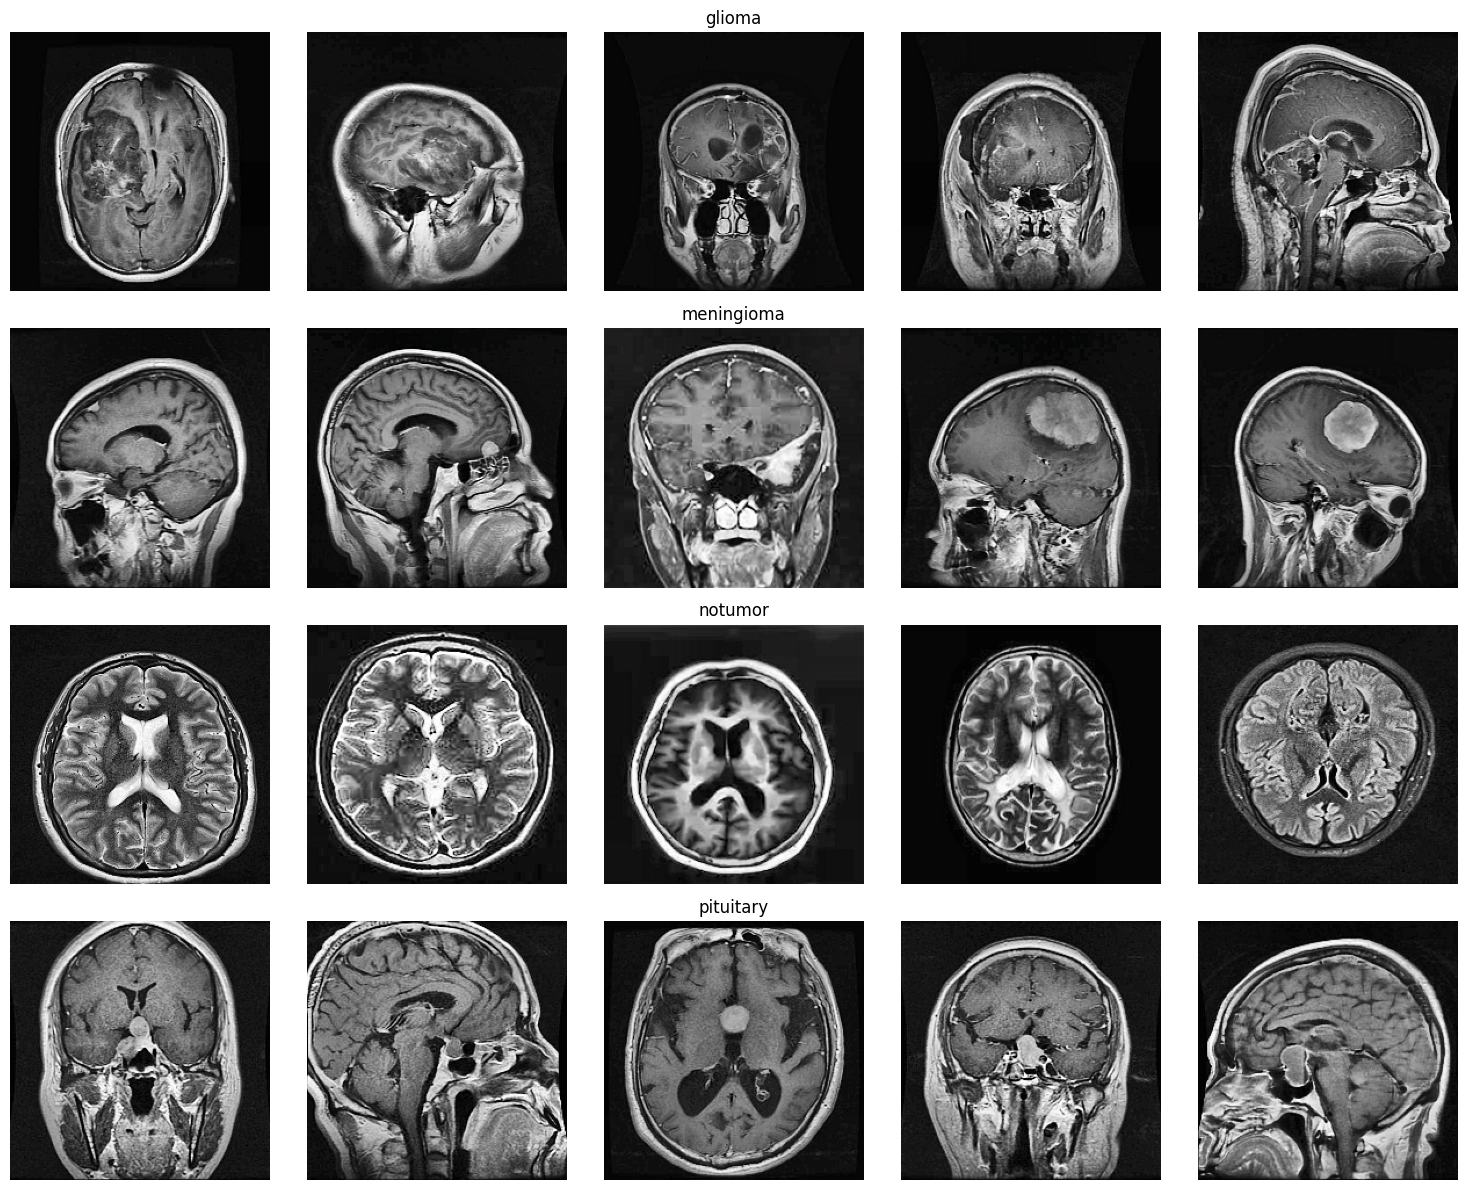


✅ Preprocessed images saved in: /kaggle/working/preprocessed_dataset


In [ ]:
import os
import cv2
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

# Paths
input_dir = "/kaggle/working/Brain_Tumor_Merged"
output_dir = "/kaggle/working/preprocessed_dataset"
os.makedirs(output_dir, exist_ok=True)

img_size = (224, 224)
num_samples = 5
device = "cuda" if torch.cuda.is_available() else "cpu"

# Gaussian filter (GPU)
def gaussian_filter_gpu(img_tensor, kernel_size=5, sigma=1.0):
    C,H,W = img_tensor.shape
    x = torch.arange(kernel_size, dtype=torch.float32, device=img_tensor.device) - kernel_size//2
    gauss = torch.exp(-(x**2)/(2*sigma**2))
    gauss = gauss / gauss.sum()
    gauss_2d = gauss[:, None] @ gauss[None, :]
    gauss_2d = gauss_2d.expand(C,1,kernel_size,kernel_size)
    img_tensor = img_tensor.unsqueeze(0)
    img_filtered = F.conv2d(img_tensor, gauss_2d, padding=kernel_size//2, groups=C)
    return img_filtered[0]

# Classes
classes = sorted([d for d in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, d))])

fig, axes = plt.subplots(len(classes), num_samples, figsize=(15,3*len(classes)))

for i, cls in enumerate(classes):
    cls_path = os.path.join(input_dir, cls)
    save_cls_path = os.path.join(output_dir, cls)
    os.makedirs(save_cls_path, exist_ok=True)

    files = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg",".png",".jpeg"))]
    sample_files = random.sample(files, min(num_samples,len(files)))

    print(f"\nProcessing class: {cls} ({len(files)} images)")
    for file in tqdm(files, desc=f"{cls} Progress", ncols=100):
        img_path = os.path.join(cls_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # 1️⃣ Resize
        img_resized = cv2.resize(img, img_size)

        # 2️⃣ CLAHE on L channel
        lab = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
        l,a,b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge((l_clahe,a,b))
        img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

        # 3️⃣ Convert to tensor [C,H,W] in 0-1
        img_tensor = torch.from_numpy(img_clahe.transpose(2,0,1)).float().to(device)/255.0

        # 4️⃣ Gaussian smoothing
        img_blur = gaussian_filter_gpu(img_tensor, kernel_size=5, sigma=1.0)

        # 5️⃣ Sharpening (Unsharp mask)
        img_sharp = torch.clamp(1.5*img_tensor - 0.5*img_blur,0,1)

        # 6️⃣ Contrast Stretching
        min_val = img_sharp.min()
        max_val = img_sharp.max()
        img_contrast = (img_sharp - min_val)/(max_val - min_val + 1e-8)  # avoid div by zero

        # 7️⃣ Save image back to CPU
        img_final = (img_contrast.cpu().numpy()*255).astype(np.uint8).transpose(1,2,0)
        cv2.imwrite(os.path.join(save_cls_path, file), img_final)

        # Plot sample images
        if file in sample_files:
            ax = axes[i,sample_files.index(file)]
            ax.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
            ax.axis("off")
            if sample_files.index(file) == num_samples//2:
                ax.set_title(cls, fontsize=12)

plt.tight_layout()
plt.show()
print("\n✅ Preprocessed images saved in:", output_dir)


In [ ]:
import os
import shutil
import random

# Preprocessed dataset path
preprocessed_dir = "/kaggle/working/preprocessed_dataset"

# Split paths
split_base = "/kaggle/working/brain_split"
train_dir = os.path.join(split_base, "train")
val_dir   = os.path.join(split_base, "val")
test_dir  = os.path.join(split_base, "test")


for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

# Split ratios
train_ratio = 0.80
val_ratio = 0.10
test_ratio = 0.10

classes = sorted(os.listdir(preprocessed_dir))

for cls in classes:
    cls_path = os.path.join(preprocessed_dir, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.shuffle(files)

    n_total = len(files)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)
    n_test = n_total - n_train - n_val

    splits = {
        train_dir: files[:n_train],
        val_dir: files[n_train:n_train+n_val],
        test_dir: files[n_train+n_val:]
    }

    for split_folder, split_files in splits.items():
        cls_split_path = os.path.join(split_folder, cls)
        os.makedirs(cls_split_path, exist_ok=True)
        for f in split_files:
            shutil.copy(os.path.join(cls_path, f), os.path.join(cls_split_path, f))

print("✅ Dataset split into 80-10-10 and saved in:", split_base)


✅ Dataset split into 80-10-10 and saved in: /kaggle/working/brain_split


In [ ]:
import os

split_base = "/kaggle/working/brain_split"
splits = ["train", "val", "test"]

for split in splits:
    split_path = os.path.join(split_base, split)
    print(f"\n📂 {split.capitalize()} Split:")
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        num_images = len([f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        print(f"{cls}: {num_images} images")



📂 Train Split:
glioma: 1296 images
meningioma: 1316 images
notumor: 1600 images
pituitary: 1405 images

📂 Val Split:
glioma: 162 images
meningioma: 164 images
notumor: 200 images
pituitary: 175 images

📂 Test Split:
glioma: 163 images
meningioma: 165 images
notumor: 200 images
pituitary: 177 images


In [ ]:
import os
import cv2
import numpy as np
import random

train_dir = "/kaggle/working/brain_split/train"
aug_train_dir = "/kaggle/working/brain_train_aug"
os.makedirs(aug_train_dir, exist_ok=True)

# =========================
# Augmentation functions
# =========================
def random_flip(img):
    flip_code = random.choice([-1, 0, 1])
    return cv2.flip(img, flip_code)

def random_rotate(img):
    angle = random.uniform(-25, 25)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 2)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def random_zoom(img):
    zoom_factor = random.uniform(0.8, 1.2)
    h, w = img.shape[:2]
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    img_resized = cv2.resize(img, (new_w, new_h))
    if zoom_factor < 1:
        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2
        img_padded = cv2.copyMakeBorder(
            img_resized, pad_h, h - new_h - pad_h,
            pad_w, w - new_w - pad_w, cv2.BORDER_REFLECT
        )
        return img_padded
    else:
        start_h = (new_h - h) // 2
        start_w = (new_w - w) // 2
        return img_resized[start_h:start_h + h, start_w:start_w + w]

def random_brightness(img):
    factor = random.uniform(0.7, 1.3)
    img = img.astype(np.float32) * factor
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

augmentations = [random_flip, random_rotate, random_zoom, random_brightness]

# =========================
# Apply augmentations (2 augmentations per image)
# =========================
classes = sorted(os.listdir(train_dir))
for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    save_cls_path = os.path.join(aug_train_dir, cls)
    os.makedirs(save_cls_path, exist_ok=True)

    for file in os.listdir(cls_path):
        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        img_path = os.path.join(cls_path, file)
        img = cv2.imread(img_path)

        # Save original image
        cv2.imwrite(os.path.join(save_cls_path, file), img)

        # Apply TWO random augmentations
        aug_funcs = random.sample(augmentations, 2)
        aug_img = img.copy()

        for i, aug_func in enumerate(aug_funcs):
            aug_img = aug_func(aug_img)
            filename, ext = os.path.splitext(file)
            aug_name = f"{filename}_aug{i+1}{ext}"
            cv2.imwrite(os.path.join(save_cls_path, aug_name), aug_img)

# =========================
# Print image count per class
# =========================
print("\n📊 Image count per class after augmentation:")
for cls in classes:
    cls_path = os.path.join(aug_train_dir, cls)
    count = len([f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    print(f"{cls}: {count} images")

print(f"\n✅ All train images and two augmented versions per image saved in: {aug_train_dir}")



📊 Image count per class after augmentation:
glioma: 3888 images
meningioma: 3948 images
notumor: 4800 images
pituitary: 4215 images

✅ All train images and two augmented versions per image saved in: /kaggle/working/brain_train_aug


In [ ]:
!pip install GPUtil


  Preparing metadata (setup.py) ... done
  Created wheel for GPUtil: filename=GPUtil-1.4.0-py3-none-any.whl size=7392 sha256=bb77891ed5b73fb041d5f1994ff48d8e4e431889775962200f944f20f96efd57
  Stored in directory: /root/.cache/pip/wheels/2b/4d/8f/55fb4f7b9b591891e8d3f72977c4ec6c7763b39c19f0861595
Successfully built GPUtil


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth
100%|██████████| 8.79M/8.79M [00:00<00:00, 71.8MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.6335 | Val Loss: 0.1933 | Train Acc: 0.8440 | Val Acc: 0.9472
Epoch [2/50] | Train Loss: 0.1783 | Val Loss: 0.1073 | Train Acc: 0.9483 | Val Acc: 0.9658
Epoch [3/50] | Train Loss: 0.0928 | Val Loss: 0.0599 | Train Acc: 0.9733 | Val Acc: 0.9872
Epoch [4/50] | Train Loss: 0.0582 | Val Loss: 0.0683 | Train Acc: 0.9836 | Val Acc: 0.9843
Epoch [5/50] | Train Loss: 0.0467 | Val Loss: 0.0542 | Train Acc: 0.9866 | Val Acc: 0.9843
Epoch [6/50] | Train Loss: 0.0270 | Val Loss: 0.0615 | Train Acc: 0.9929 | Val Acc: 0.9815
Epoch [7/50] | Train Loss: 0.0233 | Val Loss: 0.0582 | Train Acc: 0.9931 | Val Acc: 0.9843
Epoch [8/50] | Train Loss: 0.0177 | Val Loss: 0.0656 | Train Acc: 0.9955 | Val Acc: 0.9829
Epoch [9/50] | Train Loss: 0.0116 | Val Loss: 0.0713 | Train Acc: 0.9974 | Val Acc: 0.9857
Epoch [10/50] | Train Loss: 0.0114 | Val Loss: 0.0585 | Train Acc: 0.9969 | Val Acc: 0.9815
Early stopping triggered.


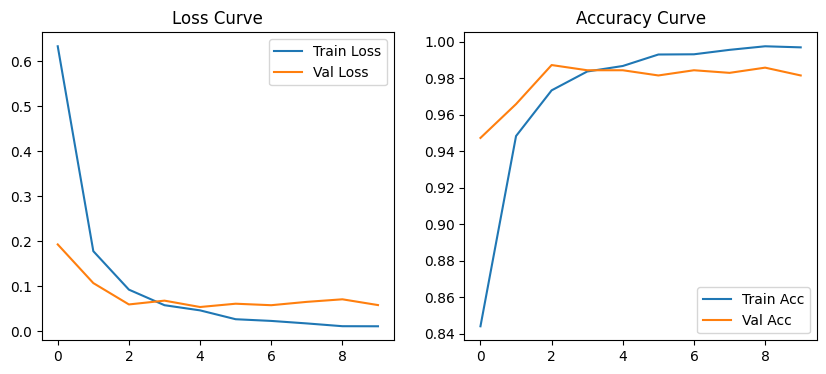


Training completed in 421.43 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9977    0.9992    0.9985      3888
  meningioma     0.9990    0.9970    0.9980      3948
     notumor     0.9988    0.9998    0.9993      4800
   pituitary     0.9995    0.9988    0.9992      4215

    accuracy                         0.9988     16851
   macro avg     0.9987    0.9987    0.9987     16851
weighted avg     0.9988    0.9988    0.9988     16851


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9699    0.9938    0.9817       162
  meningioma     0.9811    0.9512    0.9659       164
     notumor     0.9901    1.0000    0.9950       200
   pituitary     0.9943    0.9886    0.9914       175

    accuracy                         0.9843       701
   macro avg     0.9838    0.9834    0.9835       701
weighted avg     0.9844    0.9843    0.9842       701


=== Test Cl

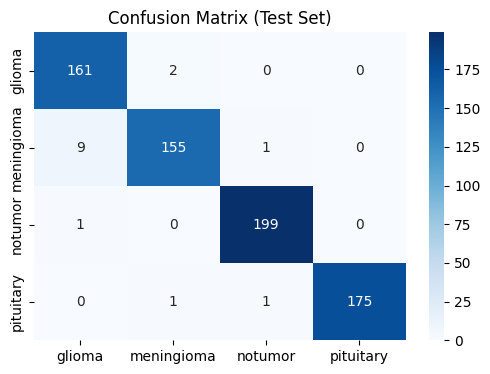


Cohen’s Kappa: 0.9716
Mean PPV: 0.9781
Mean NPV: 0.9931
Mean Sensitivity: 0.9777
Mean Specificity: 0.9930


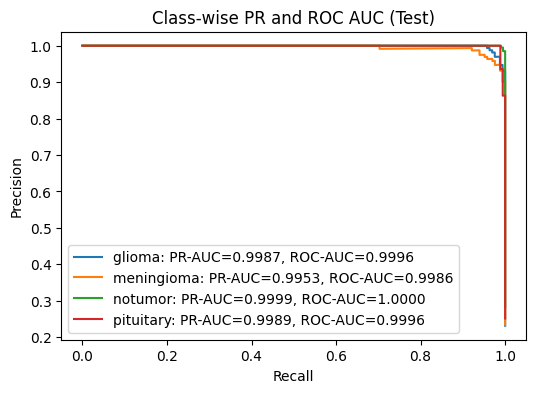


Accuracy: 0.9787
95% Confidence Interval: (0.9674, 0.9887)

GPU Memory Used: 38.55 MB
RAM Used: 2.26 GB
Inference Time: 1.18 seconds
Training Time: 421.43 seconds

Permutation Test p-value (accuracy vs random): 0.0000


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - ShuffleNetV2 (Baseline)
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, cohen_kappa_score,
    roc_auc_score, precision_recall_curve, auc
)
from scipy import stats

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_train_aug"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ ShuffleNetV2 Baseline Model
# ============================================================

class ShuffleNetV2_Baseline(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.shufflenet_v2_x1_0(weights='IMAGENET1K_V1')
        self.features = nn.Sequential(*(list(base_model.children())[:-1]))
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.mean(dim=[2,3])
        x = self.fc(x)
        return x

model = ShuffleNetV2_Baseline(num_classes=num_classes).to(device)

# ============================================================
# 3️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 4️⃣ Training Loop
# ============================================================

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val

        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "shuffle_baseline_model.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    # Plot curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 5️⃣ Simple Evaluation Function
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# ============================================================
# 6️⃣ Test Evaluation
# ============================================================

def evaluate_test(model, loader, training_time):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))

    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

    # ===================== Permutation Test =====================
    n_permutations = 100
    perm_accs = []
    y_true_arr = np.array(y_true)
    for _ in range(n_permutations):
        perm_labels = np.random.permutation(y_true_arr)
        perm_accs.append(np.mean(perm_labels == y_pred))
    perm_accs = np.array(perm_accs)
    p_value = np.mean(perm_accs >= acc)
    print(f"\nPermutation Test p-value (accuracy vs random): {p_value:.4f}")

# ============================================================
# 7️⃣ Train + Evaluate
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("shuffle_baseline_model.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")
evaluate_test(model, test_loader, training_time)


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


100%|██████████| 4.73M/4.73M [00:00<00:00, 103MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.5499 | Val Loss: 0.1997 | Train Acc: 0.7912 | Val Acc: 0.9358
Epoch [2/50] | Train Loss: 0.2774 | Val Loss: 0.1294 | Train Acc: 0.9018 | Val Acc: 0.9444
Epoch [3/50] | Train Loss: 0.1973 | Val Loss: 0.1071 | Train Acc: 0.9317 | Val Acc: 0.9601
Epoch [4/50] | Train Loss: 0.1563 | Val Loss: 0.1035 | Train Acc: 0.9462 | Val Acc: 0.9629
Epoch [5/50] | Train Loss: 0.1388 | Val Loss: 0.0771 | Train Acc: 0.9510 | Val Acc: 0.9743
Epoch [6/50] | Train Loss: 0.1079 | Val Loss: 0.0947 | Train Acc: 0.9621 | Val Acc: 0.9615
Epoch [7/50] | Train Loss: 0.0909 | Val Loss: 0.1087 | Train Acc: 0.9684 | Val Acc: 0.9615
Epoch [8/50] | Train Loss: 0.0804 | Val Loss: 0.1246 | Train Acc: 0.9726 | Val Acc: 0.9544
Epoch [9/50] | Train Loss: 0.0444 | Val Loss: 0.0885 | Train Acc: 0.9848 | Val Acc: 0.9729
Epoch [10/50] | Train Loss: 0.0374 | Val Loss: 0.0729 | Train Acc: 0.9871 | Val Acc: 0.9715
Epoch [11/50] | Train Loss: 0.0361 | Val Loss: 0.0702 | Train Acc: 0.9882 | Val Acc: 0.98

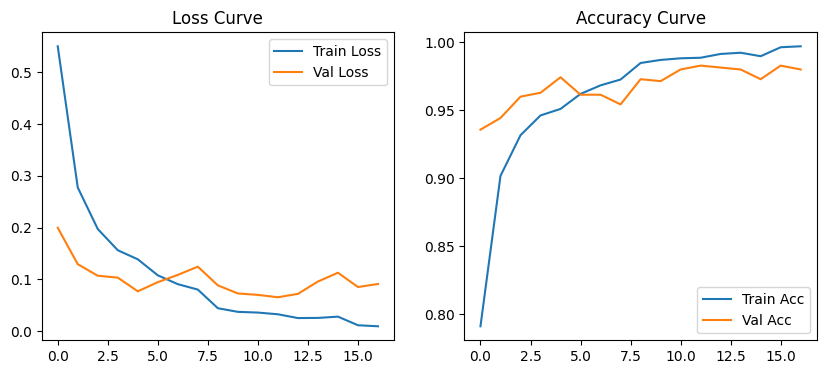


Training completed in 684.18 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9997    0.9869    0.9933      3888
  meningioma     0.9959    0.9863    0.9911      3948
     notumor     0.9808    1.0000    0.9903      4800
   pituitary     0.9969    0.9955    0.9962      4215

    accuracy                         0.9926     16851
   macro avg     0.9933    0.9922    0.9927     16851
weighted avg     0.9927    0.9926    0.9926     16851


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9693    0.9753    0.9723       162
  meningioma     0.9750    0.9512    0.9630       164
     notumor     0.9950    1.0000    0.9975       200
   pituitary     0.9887    1.0000    0.9943       175

    accuracy                         0.9829       701
   macro avg     0.9820    0.9816    0.9818       701
weighted avg     0.9828    0.9829    0.9828       701


=== Test Cl

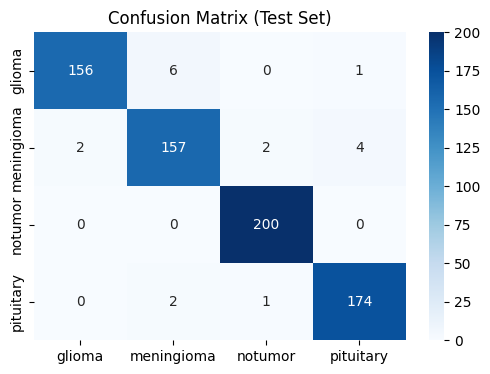


Cohen’s Kappa: 0.9659
Mean PPV: 0.9740
Mean NPV: 0.9917
Mean Sensitivity: 0.9729
Mean Specificity: 0.9915


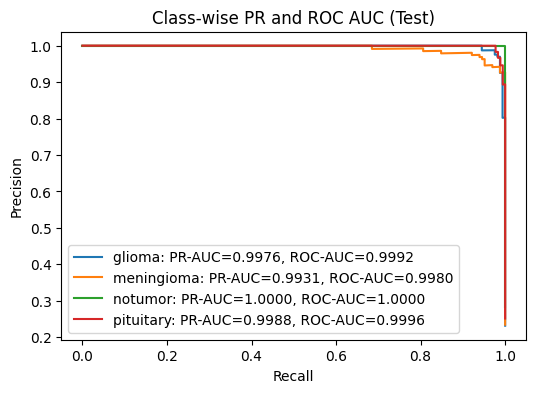


Accuracy: 0.9745
95% Confidence Interval: (0.9617, 0.9858)

GPU Memory Used: 30.20 MB
RAM Used: 2.26 GB
Inference Time: 1.19 seconds
Training Time: 684.18 seconds

Permutation Test p-value (accuracy vs random): 0.0000


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - SqueezeNet
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, cohen_kappa_score,
    roc_auc_score, precision_recall_curve, auc
)
from scipy import stats

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_train_aug"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ Plain SqueezeNet
# ============================================================

class SqueezeNet_Baseline(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.squeezenet1_1(weights='IMAGENET1K_V1')
        self.features = base_model.features
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.mean(dim=[2, 3])
        x = self.fc(x)
        return x

model = SqueezeNet_Baseline(num_classes=num_classes).to(device)

# ============================================================
# 3️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 4️⃣ Evaluation Helper
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# ============================================================
# 5️⃣ Training Loop
# ============================================================

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val

        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_squeezenet_baseline.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    # Plot curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 6️⃣ Training + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_squeezenet_baseline.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 7️⃣ Test Evaluation
# ============================================================

def evaluate_test(model, loader, training_time):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))

    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

    # ===================== Permutation Test =====================
    n_permutations = 100
    perm_accs = []
    y_true_arr = np.array(y_true)
    for _ in range(n_permutations):
        perm_labels = np.random.permutation(y_true_arr)
        perm_accs.append(np.mean(perm_labels == y_pred))
    perm_accs = np.array(perm_accs)
    p_value = np.mean(perm_accs >= acc)
    print(f"\nPermutation Test p-value (accuracy vs random): {p_value:.4f}")

# ============================================================
# 8️⃣ Evaluate Test Set
# ============================================================

evaluate_test(model, test_loader, training_time)


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 124MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.2399 | Val Loss: 0.0913 | Train Acc: 0.9137 | Val Acc: 0.9715
Epoch [2/50] | Train Loss: 0.0743 | Val Loss: 0.0645 | Train Acc: 0.9751 | Val Acc: 0.9829
Epoch [3/50] | Train Loss: 0.0383 | Val Loss: 0.0866 | Train Acc: 0.9871 | Val Acc: 0.9800
Epoch [4/50] | Train Loss: 0.0245 | Val Loss: 0.0905 | Train Acc: 0.9921 | Val Acc: 0.9757
Epoch [5/50] | Train Loss: 0.0153 | Val Loss: 0.0872 | Train Acc: 0.9954 | Val Acc: 0.9786
Epoch [6/50] | Train Loss: 0.0091 | Val Loss: 0.0727 | Train Acc: 0.9974 | Val Acc: 0.9829
Epoch [7/50] | Train Loss: 0.0048 | Val Loss: 0.0802 | Train Acc: 0.9985 | Val Acc: 0.9800
Early stopping triggered.


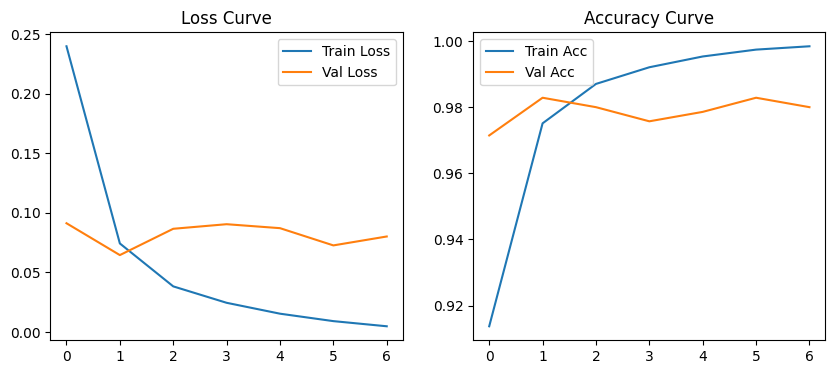


Training completed in 457.99 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9990    0.9900    0.9944      3888
  meningioma     0.9897    0.9949    0.9923      3948
     notumor     0.9992    0.9979    0.9985      4800
   pituitary     0.9939    0.9986    0.9962      4215

    accuracy                         0.9955     16851
   macro avg     0.9954    0.9953    0.9954     16851
weighted avg     0.9956    0.9955    0.9956     16851


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9641    0.9938    0.9787       162
  meningioma     0.9812    0.9573    0.9691       164
     notumor     1.0000    0.9850    0.9924       200
   pituitary     0.9831    0.9943    0.9886       175

    accuracy                         0.9829       701
   macro avg     0.9821    0.9826    0.9822       701
weighted avg     0.9831    0.9829    0.9829       701


=== Test Cl

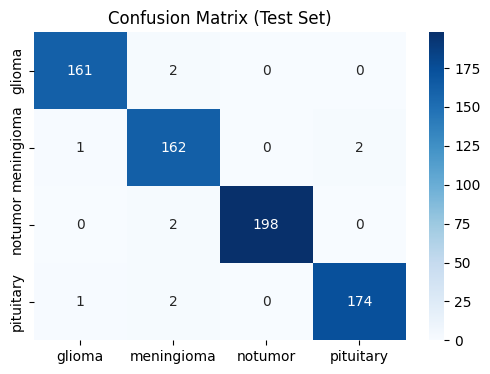


Cohen’s Kappa: 0.9810
Mean PPV: 0.9852
Mean NPV: 0.9953
Mean Sensitivity: 0.9856
Mean Specificity: 0.9954


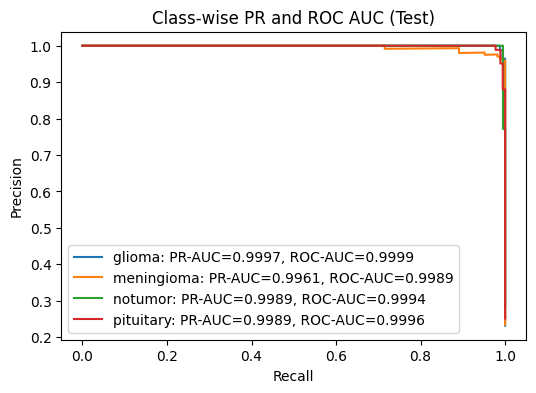


Accuracy: 0.9858
95% Confidence Interval: (0.9759, 0.9943)


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 16447.99it/s]

Permutation-based accuracy p-value: 0.0000

GPU Memory Used: 54.21 MB
RAM Used: 2.63 GB
Inference Time: 1.36 seconds
Training Time: 457.99 seconds


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - MobileNetV2
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc
from scipy import stats
from tqdm import tqdm

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_train_aug"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ MobileNetV2
# ============================================================

class MobileNetV2_Baseline(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')
        self.features = base_model.features
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.mean(dim=[2,3])
        x = self.fc(x)
        return x

model = MobileNetV2_Baseline(num_classes=num_classes).to(device)

# ============================================================
# 3️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 4️⃣ Training Loop
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val

        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_mobilenetv2_baseline.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    # Plot curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 5️⃣ Training + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_mobilenetv2_baseline.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 6️⃣ Test Evaluation (Detailed) + Permutation Accuracy
# ============================================================

def evaluate_test(model, loader, n_permutations=1000):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    # --- Classification Report ---
    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    # --- Cohen's Kappa ---
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    # --- Mean PPV, NPV, Sensitivity, Specificity ---
    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))
    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    # --- ROC & PR Curves ---
    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # --- Accuracy and 95% CI ---
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    # --- Permutation-based accuracy ---
    perm_acc = []
    y_true_arr = np.array(y_true)
    for _ in tqdm(range(n_permutations), desc="Permutation test"):
        y_perm = np.random.permutation(y_true_arr)
        perm_acc.append(np.mean(y_perm == np.array(y_pred)))
    perm_acc = np.array(perm_acc)
    p_value = np.mean(perm_acc >= acc)
    print(f"Permutation-based accuracy p-value: {p_value:.4f}")

    # --- Resource Usage ---
    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

# ============================================================
# Run Test Evaluation
# ============================================================

evaluate_test(model, test_loader, n_permutations=1000)


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████| 77.4M/77.4M [00:00<00:00, 82.2MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.1753 | Val Loss: 0.0446 | Train Acc: 0.9401 | Val Acc: 0.9872
Epoch [2/50] | Train Loss: 0.0455 | Val Loss: 0.0256 | Train Acc: 0.9863 | Val Acc: 0.9929
Epoch [3/50] | Train Loss: 0.0286 | Val Loss: 0.0298 | Train Acc: 0.9915 | Val Acc: 0.9914
Epoch [4/50] | Train Loss: 0.0210 | Val Loss: 0.0344 | Train Acc: 0.9935 | Val Acc: 0.9900
Epoch [5/50] | Train Loss: 0.0156 | Val Loss: 0.0458 | Train Acc: 0.9954 | Val Acc: 0.9872
Epoch [6/50] | Train Loss: 0.0036 | Val Loss: 0.0236 | Train Acc: 0.9992 | Val Acc: 0.9929
Epoch [7/50] | Train Loss: 0.0040 | Val Loss: 0.0307 | Train Acc: 0.9989 | Val Acc: 0.9929
Epoch [8/50] | Train Loss: 0.0031 | Val Loss: 0.0256 | Train Acc: 0.9992 | Val Acc: 0.9914
Epoch [9/50] | Train Loss: 0.0049 | Val Loss: 0.0380 | Train Acc: 0.9990 | Val Acc: 0.9900
Epoch [10/50] | Train Loss: 0.0012 | Val Loss: 0.0338 | Train Acc: 0.9998 | Val Acc: 0.9957
Epoch [11/50] | Train Loss: 0.0005 | Val Loss: 0.0325 | Train Acc: 0.9999 | Val Acc: 0.99

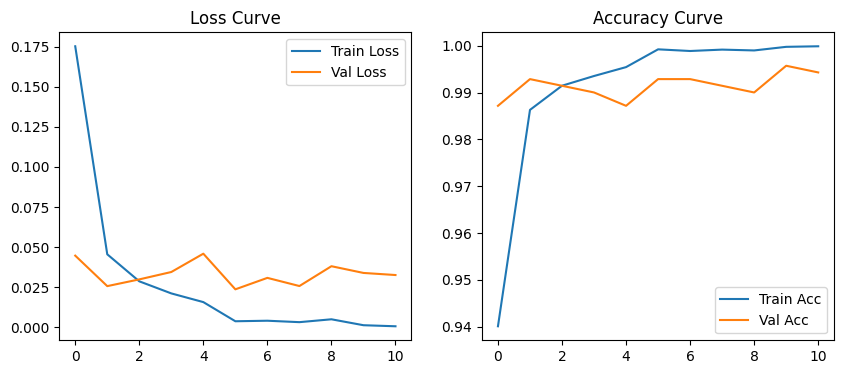


Training completed in 1943.21 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     1.0000    1.0000    1.0000      3888
  meningioma     0.9997    0.9990    0.9994      3948
     notumor     0.9998    1.0000    0.9999      4800
   pituitary     0.9993    0.9998    0.9995      4215

    accuracy                         0.9997     16851
   macro avg     0.9997    0.9997    0.9997     16851
weighted avg     0.9997    0.9997    0.9997     16851


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9877    0.9938    0.9908       162
  meningioma     0.9877    0.9817    0.9847       164
     notumor     1.0000    1.0000    1.0000       200
   pituitary     0.9943    0.9943    0.9943       175

    accuracy                         0.9929       701
   macro avg     0.9924    0.9925    0.9924       701
weighted avg     0.9929    0.9929    0.9929       701


=== Test C

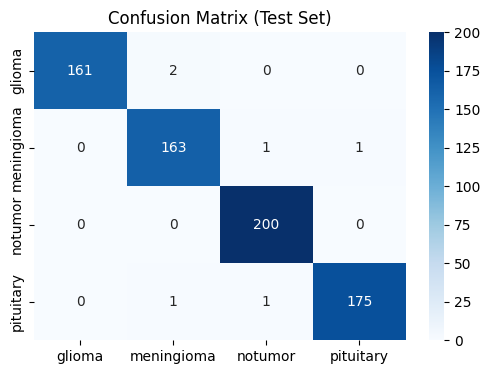


Cohen’s Kappa: 0.9886
Mean PPV: 0.9916
Mean NPV: 0.9972
Mean Sensitivity: 0.9911
Mean Specificity: 0.9971


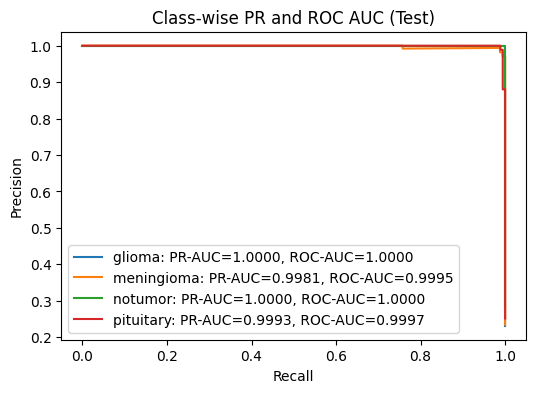


Accuracy: 0.9915
95% Confidence Interval: (0.9844, 0.9972)


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 15271.78it/s]

Permutation-based accuracy p-value: 0.0000

GPU Memory Used: 296.71 MB
RAM Used: 2.74 GB
Inference Time: 3.08 seconds
Training Time: 1943.21 seconds


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - DenseNet201
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc
from scipy import stats
from tqdm import tqdm

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_train_aug"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ DenseNet201
# ============================================================

class DenseNet201(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.densenet201(weights='IMAGENET1K_V1')
        self.features = base_model.features
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1920, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = F.relu(x, inplace=True)
        x = x.mean(dim=[2,3])
        x = self.fc(x)
        return x

model = DenseNet201(num_classes=num_classes).to(device)

# ============================================================
# 3️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 4️⃣ Training Loop
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val

        scheduler.step(avg_val_loss)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_densenet201.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 5️⃣ Train + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_densenet201.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 6️⃣ Test Evaluation (Detailed) + Permutation Accuracy
# ============================================================

def evaluate_test(model, loader, n_permutations=1000):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))
    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    perm_acc = []
    y_true_arr = np.array(y_true)
    for _ in tqdm(range(n_permutations), desc="Permutation test"):
        y_perm = np.random.permutation(y_true_arr)
        perm_acc.append(np.mean(y_perm == np.array(y_pred)))
    perm_acc = np.array(perm_acc)
    p_value = np.mean(perm_acc >= acc)
    print(f"Permutation-based accuracy p-value: {p_value:.4f}")

    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

# ============================================================
# Run Test Evaluation
# ============================================================

evaluate_test(model, test_loader, n_permutations=1000)


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.2243 | Val Loss: 0.0537 | Train Acc: 0.9281 | Val Acc: 0.9872
Epoch [2/50] | Train Loss: 0.0341 | Val Loss: 0.0420 | Train Acc: 0.9899 | Val Acc: 0.9886
Epoch [3/50] | Train Loss: 0.0229 | Val Loss: 0.0331 | Train Acc: 0.9928 | Val Acc: 0.9900
Epoch [4/50] | Train Loss: 0.0139 | Val Loss: 0.0614 | Train Acc: 0.9963 | Val Acc: 0.9843
Epoch [5/50] | Train Loss: 0.0123 | Val Loss: 0.0579 | Train Acc: 0.9967 | Val Acc: 0.9872
Epoch [6/50] | Train Loss: 0.0107 | Val Loss: 0.0542 | Train Acc: 0.9968 | Val Acc: 0.9829
Epoch [7/50] | Train Loss: 0.0064 | Val Loss: 0.0374 | Train Acc: 0.9982 | Val Acc: 0.9900
Epoch [8/50] | Train Loss: 0.0023 | Val Loss: 0.0590 | Train Acc: 0.9993 | Val Acc: 0.9886
Early stopping triggered.


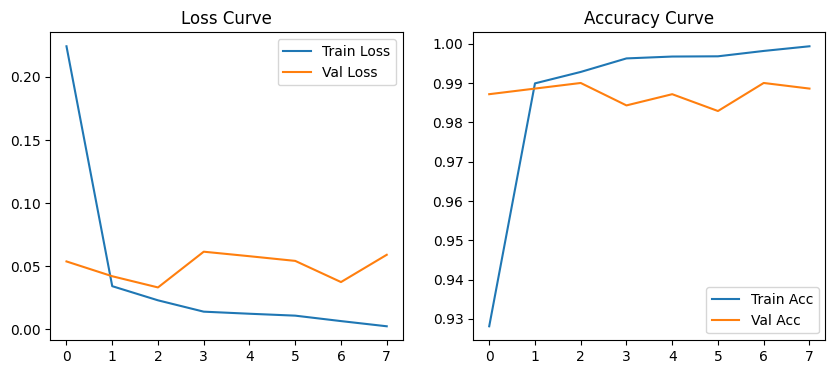


Training completed in 1429.63 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     1.0000    0.9997    0.9999      3888
  meningioma     0.9975    0.9997    0.9986      3948
     notumor     0.9994    0.9998    0.9996      4800
   pituitary     1.0000    0.9976    0.9988      4215

    accuracy                         0.9992     16851
   macro avg     0.9992    0.9992    0.9992     16851
weighted avg     0.9992    0.9992    0.9992     16851


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9816    0.9877    0.9846       162
  meningioma     0.9758    0.9817    0.9787       164
     notumor     1.0000    1.0000    1.0000       200
   pituitary     1.0000    0.9886    0.9943       175

    accuracy                         0.9900       701
   macro avg     0.9893    0.9895    0.9894       701
weighted avg     0.9901    0.9900    0.9900       701


=== Test C

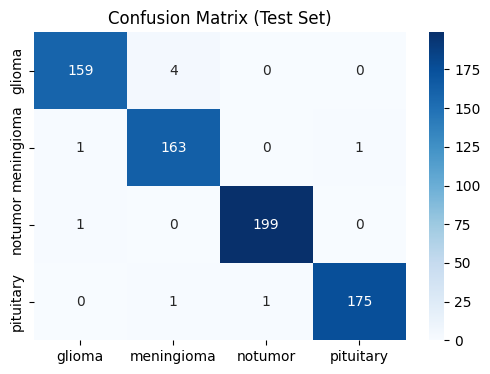


Cohen’s Kappa: 0.9829
Mean PPV: 0.9868
Mean NPV: 0.9958
Mean Sensitivity: 0.9868
Mean Specificity: 0.9958


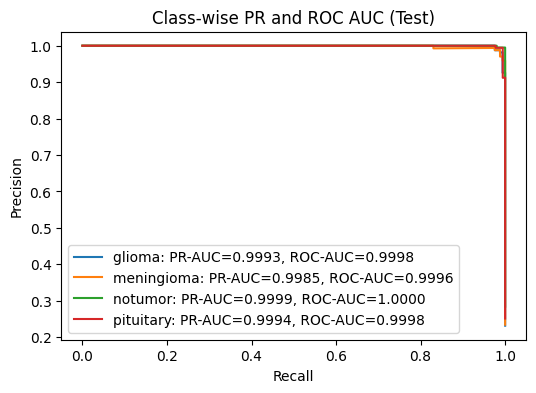


Accuracy: 0.9872
95% Confidence Interval: (0.9787, 0.9943)


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 15858.92it/s]

Permutation-based accuracy p-value: 0.0000

GPU Memory Used: 338.84 MB
RAM Used: 2.81 GB
Inference Time: 2.63 seconds
Training Time: 1429.63 seconds


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - Xception
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc
from scipy import stats
from tqdm import tqdm

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_train_aug"
val_dir   = "/kaggle/working/brain_split/val"
test_dir  = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds   = datasets.ImageFolder(val_dir, transform=transform)
test_ds  = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ Xception Base Model
# ============================================================

class XceptionNet(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = timm.create_model('xception', pretrained=True, features_only=True)
        self.features = base_model
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)[-1]
        x = x.mean(dim=[2, 3])
        x = self.fc(x)
        return x

model = XceptionNet(num_classes=num_classes).to(device)

# ============================================================
# 3️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 4️⃣ Training Loop
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        # Validation
        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val
        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_xception.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 5️⃣ Train + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_xception.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 6️⃣ Test Evaluation (Detailed)
# ============================================================

def evaluate_test(model, loader, n_permutations=1000):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    # --- Mean PPV, NPV, Sensitivity, Specificity ---
    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))
    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    # --- ROC & PR Curves ---
    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # --- Accuracy and CI ---
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    # --- Permutation Test ---
    perm_acc = []
    y_true_arr = np.array(y_true)
    for _ in tqdm(range(n_permutations), desc="Permutation test"):
        y_perm = np.random.permutation(y_true_arr)
        perm_acc.append(np.mean(y_perm == np.array(y_pred)))
    perm_acc = np.array(perm_acc)
    p_value = np.mean(perm_acc >= acc)
    print(f"Permutation-based accuracy p-value: {p_value:.4f}")

    # --- Resource Usage ---
    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

# ============================================================
# Run Test Evaluation
# ============================================================

evaluate_test(model, test_loader, n_permutations=1000)


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:02<00:00, 72.3MB/s] 
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.2052 | Val Loss: 0.0884 | Train Acc: 0.9284 | Val Acc: 0.9829
Epoch [2/50] | Train Loss: 0.0699 | Val Loss: 0.0537 | Train Acc: 0.9760 | Val Acc: 0.9843
Epoch [3/50] | Train Loss: 0.0403 | Val Loss: 0.0877 | Train Acc: 0.9870 | Val Acc: 0.9772
Epoch [4/50] | Train Loss: 0.0377 | Val Loss: 0.0539 | Train Acc: 0.9888 | Val Acc: 0.9857
Epoch [5/50] | Train Loss: 0.0215 | Val Loss: 0.0381 | Train Acc: 0.9939 | Val Acc: 0.9914
Epoch [6/50] | Train Loss: 0.0312 | Val Loss: 0.0329 | Train Acc: 0.9900 | Val Acc: 0.9914
Epoch [7/50] | Train Loss: 0.0266 | Val Loss: 0.0408 | Train Acc: 0.9919 | Val Acc: 0.9929
Epoch [8/50] | Train Loss: 0.0184 | Val Loss: 0.0550 | Train Acc: 0.9944 | Val Acc: 0.9857
Epoch [9/50] | Train Loss: 0.0199 | Val Loss: 0.0897 | Train Acc: 0.9935 | Val Acc: 0.9843
Epoch [10/50] | Train Loss: 0.0050 | Val Loss: 0.0383 | Train Acc: 0.9985 | Val Acc: 0.9900
Epoch [11/50] | Train Loss: 0.0008 | Val Loss: 0.0312 | Train Acc: 0.9999 | Val Acc: 0.99

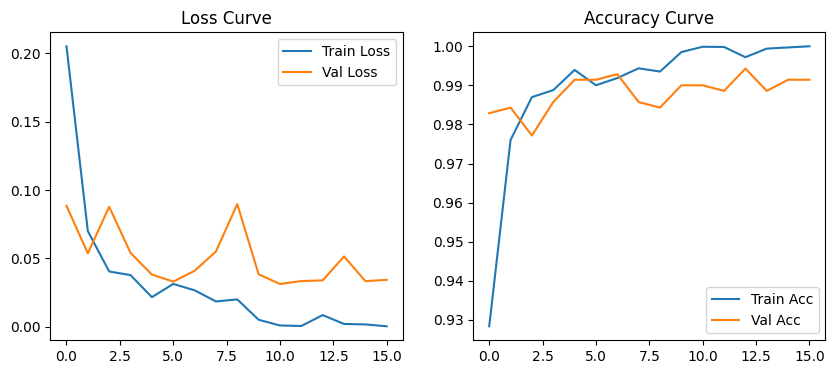


Training completed in 2681.05 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     1.0000    1.0000    1.0000      3888
  meningioma     1.0000    1.0000    1.0000      3948
     notumor     1.0000    1.0000    1.0000      4800
   pituitary     1.0000    1.0000    1.0000      4215

    accuracy                         1.0000     16851
   macro avg     1.0000    1.0000    1.0000     16851
weighted avg     1.0000    1.0000    1.0000     16851


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9758    0.9938    0.9847       162
  meningioma     0.9876    0.9695    0.9785       164
     notumor     1.0000    1.0000    1.0000       200
   pituitary     0.9943    0.9943    0.9943       175

    accuracy                         0.9900       701
   macro avg     0.9894    0.9894    0.9894       701
weighted avg     0.9901    0.9900    0.9900       701


=== Test C

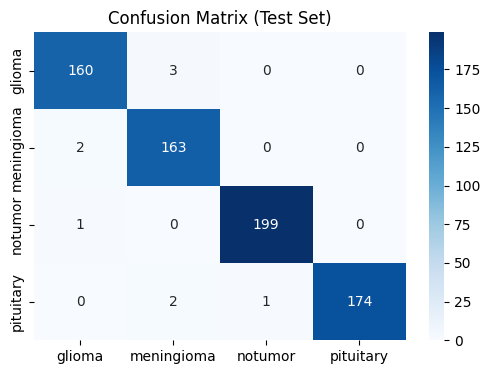


Cohen’s Kappa: 0.9829
Mean PPV: 0.9867
Mean NPV: 0.9958
Mean Sensitivity: 0.9869
Mean Specificity: 0.9958


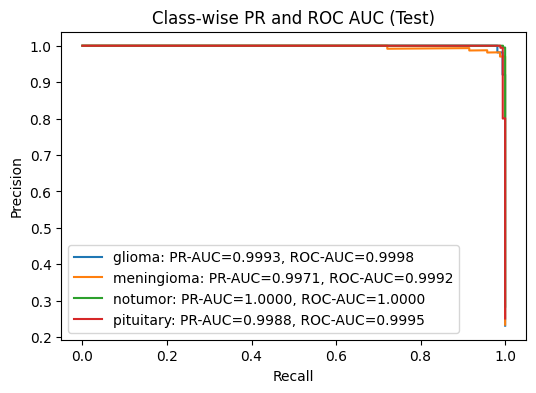


Accuracy: 0.9872
95% Confidence Interval: (0.9787, 0.9943)


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 15546.32it/s]

Permutation-based accuracy p-value: 0.0000

GPU Memory Used: 685.25 MB
RAM Used: 2.41 GB
Inference Time: 2.70 seconds
Training Time: 2681.05 seconds


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - ResNet101
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from scipy import stats

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_train_aug"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ ResNet101 Model
# ============================================================

class ResNet101(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.resnet101(weights='IMAGENET1K_V1')
        self.features = nn.Sequential(*list(base_model.children())[:-2])
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x

model = ResNet101(num_classes=num_classes).to(device)

# ============================================================
# 3️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 4️⃣ Training Loop
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        # Validation
        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val
        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_resnet101.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 5️⃣ Train + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_resnet101.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 6️⃣ Test Evaluation (Detailed)
# ============================================================

def evaluate_test(model, loader, n_permutations=1000):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    # --- Mean PPV, NPV, Sensitivity, Specificity ---
    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))
    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    # --- ROC & PR Curves ---
    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # --- Accuracy and CI ---
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    # --- Permutation Test ---
    perm_acc = []
    y_true_arr = np.array(y_true)
    for _ in tqdm(range(n_permutations), desc="Permutation test"):
        y_perm = np.random.permutation(y_true_arr)
        perm_acc.append(np.mean(y_perm == np.array(y_pred)))
    perm_acc = np.array(perm_acc)
    p_value = np.mean(perm_acc >= acc)
    print(f"Permutation-based accuracy p-value: {p_value:.4f}")

    # --- Resource Usage ---
    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

# ============================================================
# Run Test Evaluation
# ============================================================

evaluate_test(model, test_loader, n_permutations=1000)